# Project : Employee Attrition Prediction using Machine Learning


1. Business Understanding
2. Data Loading & Exploration
3. Data Cleaning & Preprocessing
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Model Building
7. Model Evaluation
8. Model Comparison
9. Feature Importance Analysis
10. Business Insights
11. HR Recommendations
12. Limitations & Future Improvements

## Problem Statement

Employee attrition is a major concern for organizations because replacing employees is expensive and impacts productivity.

The objective of this project is to build a machine learning model that predicts whether an employee is likely to leave the company and identify the key factors influencing attrition.

### Data Loading & Exploration

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [52]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")


In [93]:
df_original =  pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [94]:
df_original.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [41]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [28]:
df.shape

(1470, 35)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [30]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [31]:
# Target Variable
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [53]:
# Normalize
attrition_rate = df["Attrition"].value_counts(normalize=True)*100
attrition_rate

,proportion
Attrition,
No,83.877551
Yes,16.122449


In [54]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

categorical_cols = df.select_dtypes(include=['object']).columns

In [55]:
print("Rows : ",df.shape[0])
print("Columns : ",df.shape[1])


print("\nNumeric Columns : ",numeric_cols)
print("\nCategorical Columns : ",categorical_cols)

print("\nAttrition Rate : ",attrition_rate['Yes'])


Rows :  1470
Columns :  35

Numeric Columns :  Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

Categorical Columns :  Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

Attrition Rate :  16.122448979591837


### Data Cleaning & Preprocessing

In [35]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [56]:
# Remove Irrelevant Features
drop_col = [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

df.drop(drop_col,axis=1,inplace=True)


In [89]:
df_original.drop(drop_col,axis=1,inplace=True)


In [57]:
# Target Encoding

df['Attrition'] = df['Attrition'].map({"Yes":1,"No":0})

In [58]:
df.head(2)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7


In [59]:
# One Hot encoding

df_copy = pd.get_dummies(df,drop_first=False)

In [61]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 52 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   HourlyRate                         1470 non-null   int64
 7   JobInvolvement                     1470 non-null   int64
 8   JobLevel                           1470 non-null   int64
 9   JobSatisfaction                    1470 non-null   int64
 10  MonthlyIncome                      1470 non-null   int64
 11  MonthlyRate                        1470 non-null   int64
 12  NumCompaniesWorked  

In [64]:
# Train-Test Split
from sklearn.model_selection import train_test_split
x = df_copy.drop("Attrition",axis=1)
y = df_copy["Attrition"]

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [65]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###Exploratory Data Analysis (EDA)

In [66]:
# Attrition by Department
dept_attrition = pd.crosstab(df['Department'],df['Attrition'])
dept_attrition

Attrition,0,1
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


<Axes: xlabel='Department', ylabel='1'>

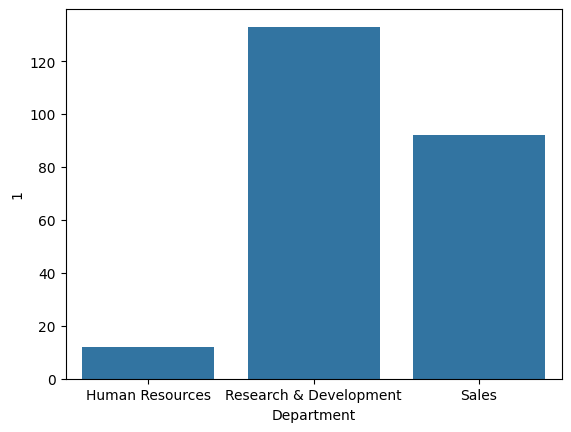

In [69]:
import seaborn as sns

sns.barplot(dept_attrition,x="Department",y=1)

In [72]:
dept_attrition["perc_drop"] = dept_attrition[1]/(dept_attrition[1]+dept_attrition[0])*100
dept_attrition

Attrition,0,1,perc_drop
Department,,,
Human Resources,51,12,19.047619
Research & Development,828,133,13.839750
Sales,354,92,20.627803


<Axes: xlabel='Department', ylabel='perc_drop'>

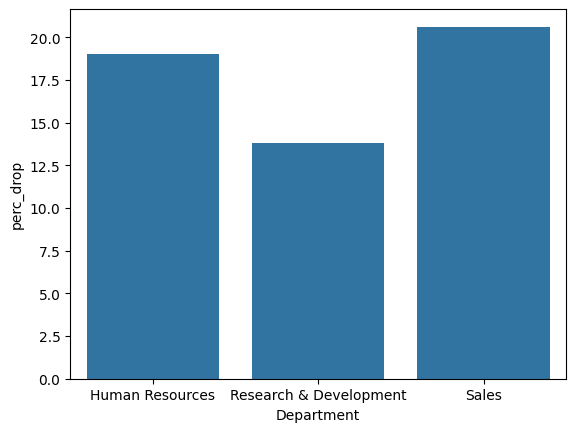

In [73]:
sns.barplot(dept_attrition,x="Department",y="perc_drop")

Which department experiences highest employee loss?

Ans :
- By Numbers : Research and Development
- By % : Sales

In [81]:
# Attrition by Job Role

job_attrition = pd.crosstab(df['JobRole'],df['Attrition'],normalize='index')
job_attrition

Attrition,0,1
JobRole,,
Healthcare Representative,0.931298,0.068702
Human Resources,0.769231,0.230769
Laboratory Technician,0.760618,0.239382
Manager,0.950980,0.049020
Manufacturing Director,0.931034,0.068966
Research Director,0.975000,0.025000
Research Scientist,0.839041,0.160959
Sales Executive,0.825153,0.174847
Sales Representative,0.602410,0.397590


<Axes: xlabel='JobRole', ylabel='1'>

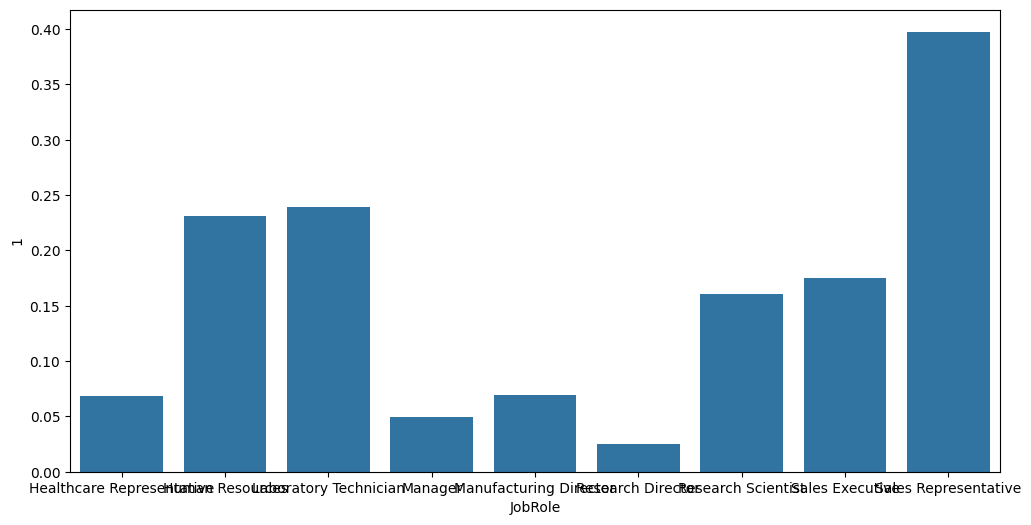

In [82]:
plt.figure(figsize=(12,6))
sns.barplot(job_attrition,x = "JobRole",y = 1)

In [83]:
job_attrition["perc_drop"] = job_attrition[1]/(job_attrition[1]+job_attrition[0])*100
job_attrition

Attrition,0,1,perc_drop
JobRole,,,
Healthcare Representative,0.931298,0.068702,6.870229
Human Resources,0.769231,0.230769,23.076923
Laboratory Technician,0.760618,0.239382,23.938224
Manager,0.950980,0.049020,4.901961
Manufacturing Director,0.931034,0.068966,6.896552
Research Director,0.975000,0.025000,2.500000
Research Scientist,0.839041,0.160959,16.095890
Sales Executive,0.825153,0.174847,17.484663
Sales Representative,0.602410,0.397590,39.759036


Which job roles are most vulnerable?

Ans :
- By Numbers : Laboratory Technician
- By % : Sales Representative

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

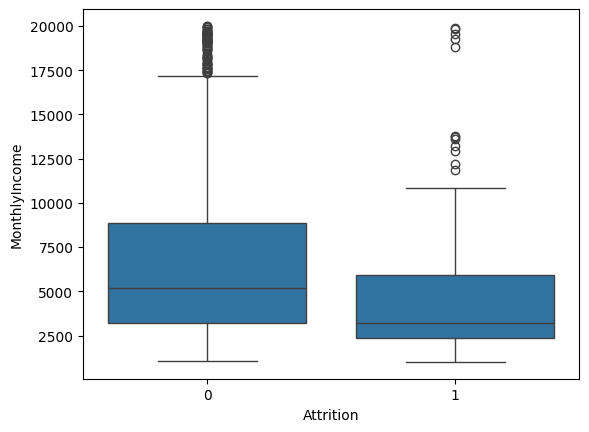

In [85]:
# Attrition vs Monthly Income

sns.boxplot(x="Attrition",y="MonthlyIncome",data=df)

Do employees with lower salaries leave more?

YES

In [107]:
# Attrition vs Work-Life Balance
work_balance = [df_original["WorkLifeBalance"].map({1:"Bad",2:"Good",3:"Better",4:"Best"}),df_original["Attrition"].map({"Yes":1,"No":0})]
work_balance = pd.DataFrame(work_balance).T
work_balance.columns = ["WorkLifeBalance","Attrition"]

<Axes: xlabel='WorkLifeBalance', ylabel='count'>

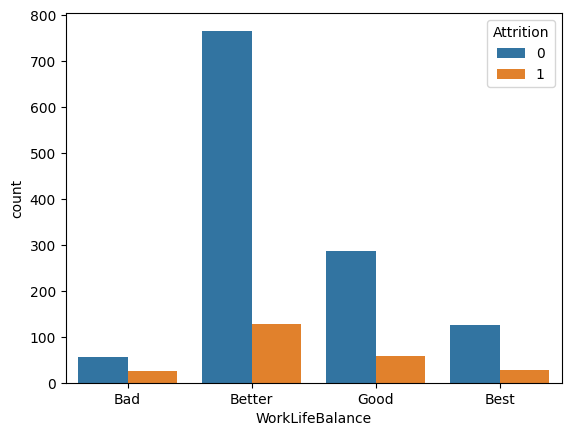

In [108]:
sns.countplot(data=work_balance,x="WorkLifeBalance",hue="Attrition")


Does poor work-life balance increase attrition?

No

<Axes: xlabel='YearsAtCompany', ylabel='Count'>

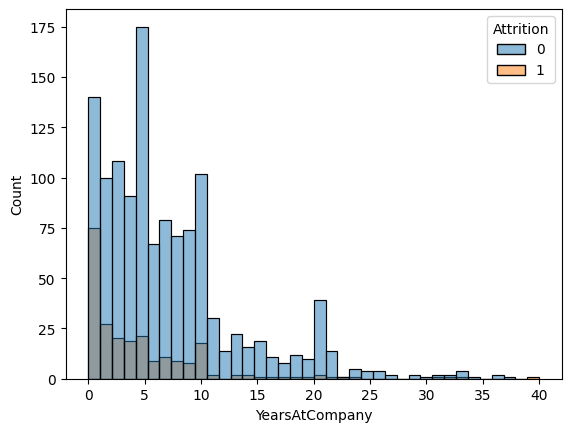

In [113]:
# Attrition vs Years At Company

sns.histplot(data=df,x="YearsAtCompany",hue="Attrition")

Most attrition occurs within the first five years of employment.

###Model Building

1. Logistic Regression

In [114]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

2. Random Forest

In [115]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

3. Gradient Boosting

In [116]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=300,
    random_state=42
)

gb.fit(X_train,y_train)

GradientBoostingClassifier(n_estimators=300, random_state=42)

### Model Evaluation

In [ ]:
# Precision
# Recall
# F1 Score
# ROC-AUC
# Confusion Matrix

In [117]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix
)

def evaluate_model(model,X_test,y_test):
    y_pred = model.predict(X_test)
    print(classification_report(y_test,y_pred))
    print("ROC-AUC Score : ",roc_auc_score(y_test,y_pred))
    print("Confusion Matrix : \n",confusion_matrix(y_test,y_pred))

In [121]:
evaluate_model(lr,X_test_scaled,y_test)

              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.33      0.60      0.43        47

    accuracy                           0.74       294
   macro avg       0.62      0.68      0.63       294
weighted avg       0.82      0.74      0.77       294

ROC-AUC Score :  0.6845120165388922
Confusion Matrix : 
 [[191  56]
 [ 19  28]]


In [122]:
evaluate_model(rf,X_test,y_test)

              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.62      0.11      0.18        47

    accuracy                           0.85       294
   macro avg       0.74      0.55      0.55       294
weighted avg       0.82      0.85      0.80       294

ROC-AUC Score :  0.547118614867775
Confusion Matrix : 
 [[244   3]
 [ 42   5]]


In [123]:
evaluate_model(gb,X_test,y_test)

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.61      0.23      0.34        47

    accuracy                           0.85       294
   macro avg       0.74      0.60      0.63       294
weighted avg       0.83      0.85      0.83       294

ROC-AUC Score :  0.6028512361099146
Confusion Matrix : 
 [[240   7]
 [ 36  11]]


In [126]:
lr_predict = lr.predict(X_test_scaled)
gb_predict = gb.predict(X_test)
rf_predict = rf.predict(X_test)

In [127]:
# Comparison Table
# (model vs (Precision , Recall , F1 , ROC-AUC))

model_list = [
    "Logistic Regression",
    "Random Forest",
    "Gradient Boosting"
]

precision_list = [
    classification_report(y_test,lr_predict,output_dict=True)['1']['precision'],
    classification_report(y_test,rf_predict,output_dict=True)['1']['precision'],
    classification_report(y_test,gb_predict,output_dict=True)['1']['precision']
]

recall_list = [
    classification_report(y_test,lr_predict,output_dict=True)['1']['recall'],
    classification_report(y_test,rf_predict,output_dict=True)['1']['recall'],
    classification_report(y_test,gb_predict,output_dict=True)['1']['recall']
]

f1_list = [
    classification_report(y_test,lr_predict,output_dict=True)['1']['f1-score'],
    classification_report(y_test,rf_predict,output_dict=True)['1']['f1-score'],
    classification_report(y_test,gb_predict,output_dict=True)['1']['f1-score']
]

roc_auc_list = [
    roc_auc_score(y_test,lr_predict),
    roc_auc_score(y_test,rf_predict),
    roc_auc_score(y_test,gb_predict)
]


In [128]:
df_eval = pd.DataFrame({
    "Model" : model_list,
    "Precision" : precision_list,
    "Recall" : recall_list,
    "F1" : f1_list,
    "ROC-AUC" : roc_auc_list
})

df_eval

,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.333333,0.595745,0.427481,0.684512
1,Random Forest,0.625000,0.106383,0.181818,0.547119
2,Gradient Boosting,0.611111,0.234043,0.338462,0.602851


### Best Model Selection

## Which Model Performed Best?

### For an Employee Attrition problem, Recall is more important than Precision.

Why?

False Negative = Employee leaves but model predicts they will stay.

HR misses the opportunity to intervene.
This is more expensive than having a few false alarms.

##Model Comparison Analysis:

1. Logistic Regression

- Highest Recall (59.6%)
- Highest F1 Score (42.7%)
- Highest ROC-AUC (68.5%)
- Detects most employees likely to leave

2. Random Forest
- Highest Precision (62.5%)
- Extremely poor Recall (10.6%)
- Misses nearly 90% of employees who actually leave

3. Gradient Boosting
- Better than Random Forest
- Still much lower Recall than Logistic Regression

### Final Model Choice

### Logistic Regression

Although Random Forest achieved higher precision,
Logistic Regression identified significantly more employees
who are at risk of leaving.

For HR retention strategies, catching potential attrition
is more important than minimizing false alarms.

Therefore Logistic Regression is selected as the final model.

### Confusion Matrix of Best Model

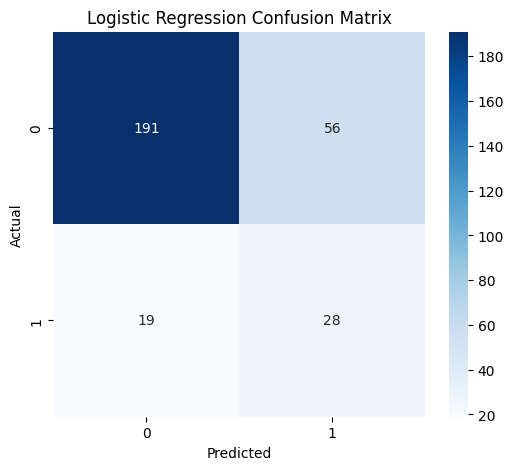

In [129]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_lr = lr.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Feature Importance

In [131]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': lr.coef_[0]
})

importance['Abs_Coefficient'] = abs(
    importance['Coefficient']
)

importance = importance.sort_values(
    'Abs_Coefficient',
    ascending=False
)

top10 = importance.head(10)
top10

,Feature,Coefficient,Abs_Coefficient
7,JobLevel,0.679315,0.679315
16,TotalWorkingYears,-0.657901,0.657901
42,JobRole_Research Director,-0.600951,0.600951
21,YearsSinceLastPromotion,0.499404,0.499404
22,YearsWithCurrManager,-0.474830,0.474830
11,NumCompaniesWorked,0.462390,0.462390
38,JobRole_Human Resources,0.457245,0.457245
39,JobRole_Laboratory Technician,0.450046,0.450046
4,EnvironmentSatisfaction,-0.441624,0.441624
26,Department_Human Resources,-0.438544,0.438544


In [132]:
top10[['Feature','Coefficient']]

,Feature,Coefficient
7,JobLevel,0.679315
16,TotalWorkingYears,-0.657901
42,JobRole_Research Director,-0.600951
21,YearsSinceLastPromotion,0.499404
22,YearsWithCurrManager,-0.474830
11,NumCompaniesWorked,0.462390
38,JobRole_Human Resources,0.457245
39,JobRole_Laboratory Technician,0.450046
4,EnvironmentSatisfaction,-0.441624
26,Department_Human Resources,-0.438544


## Visualization

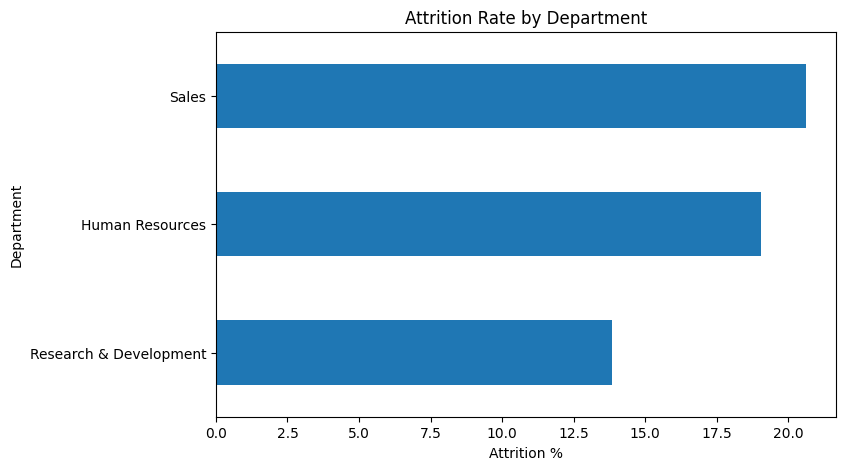

In [133]:
# Chart 1: Attrition Rate by Department and Job Roles

attrition_dept = pd.crosstab(
    df_original['Department'],
    df_original['Attrition'],
    normalize='index'
)*100

attrition_dept['Yes'].sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Attrition Rate by Department")
plt.xlabel("Attrition %")
plt.show()

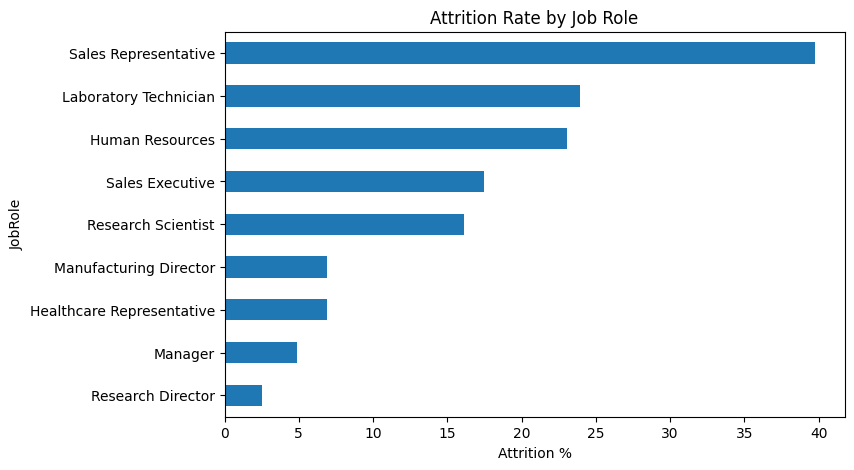

In [134]:
attrition_job = pd.crosstab(
    df_original['JobRole'],
    df_original['Attrition'],
    normalize='index'
)*100

attrition_job['Yes'].sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition %")
plt.show()

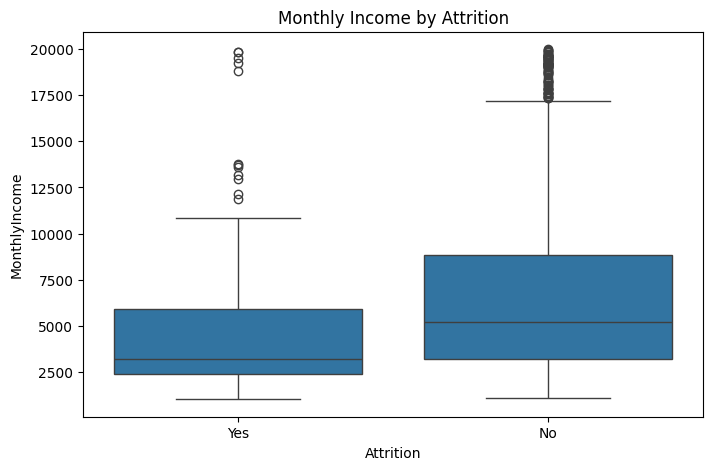

In [135]:
# Chart 2: Monthly Income vs Attrition

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df_original
)

plt.title("Monthly Income by Attrition")
plt.show()

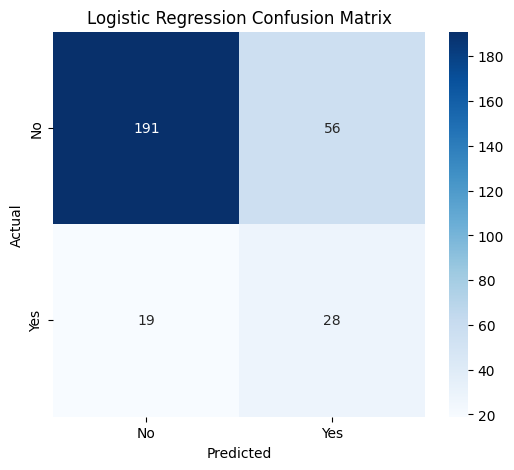

In [138]:
# Chart 3: Confusion Matrix Heatmap

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

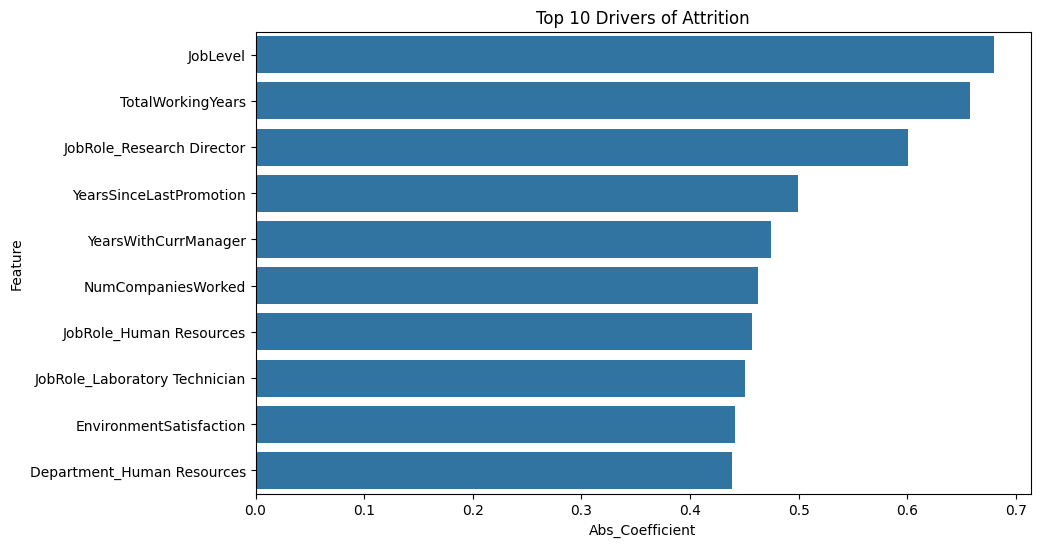

In [140]:
# Chart 4: Top 10 Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Abs_Coefficient',
    y='Feature'
)

plt.title("Top 10 Drivers of Attrition")
plt.show()



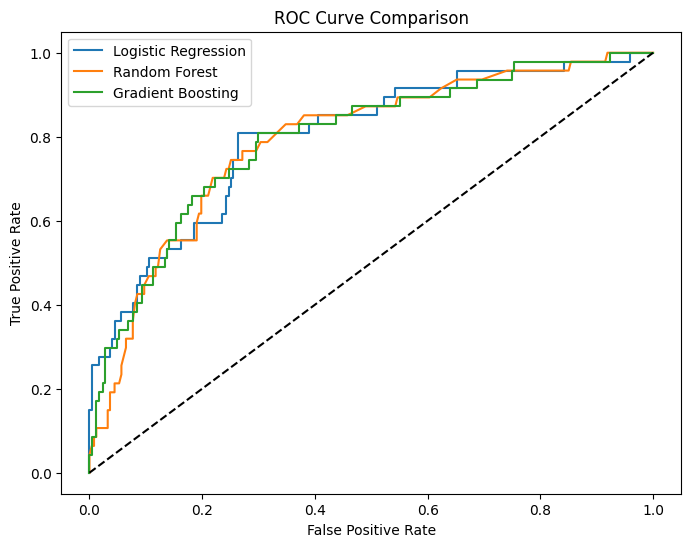

In [141]:
# Chart 5 (Bonus): ROC Curve Comparison
from sklearn.metrics import roc_curve

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

plt.figure(figsize=(8,6))

# Logistic Regression
probs = lr.predict_proba(X_test_scaled)[:,1]
fpr,tpr,_ = roc_curve(y_test, probs)
plt.plot(fpr,tpr,label='Logistic Regression')

# Random Forest
probs = rf.predict_proba(X_test)[:,1]
fpr,tpr,_ = roc_curve(y_test, probs)
plt.plot(fpr,tpr,label='Random Forest')

# Gradient Boosting
probs = gb.predict_proba(X_test)[:,1]
fpr,tpr,_ = roc_curve(y_test, probs)
plt.plot(fpr,tpr,label='Gradient Boosting')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## HR Insights & Business Recommendations


## Key Findings from EDA

### Insight 1: Sales Representatives have the highest attrition rate

Employees working as **Sales Representatives show an attrition rate of 39.76%**, meaning nearly **4 out of every 10 employees** in this role leave the company.

This is significantly higher than all other job roles and indicates a serious retention challenge.

---

### Insight 2: Sales department experiences the highest employee loss

Among all departments:

| Department             | Attrition Rate |
| ---------------------- | -------------- |
| Sales                  | 20.63%         |
| Human Resources        | 19.05%         |
| Research & Development | 13.84%         |

The **Sales department loses approximately 1 in every 5 employees**, making it the department that HR should prioritize for retention initiatives.

---

### Insight 3: Laboratory Technicians and Human Resources employees are high-risk groups

After Sales Representatives, the highest attrition rates are:

| Job Role              | Attrition Rate |
| --------------------- | -------------- |
| Sales Representative  | 39.76%         |
| Laboratory Technician | 23.94%         |
| Human Resources       | 23.08%         |

These roles experience attrition rates substantially above the company average and should receive targeted attention.

---

### Insight 4: Employee experience factors matter more than salary alone

The Logistic Regression model identified:

* Environment Satisfaction
* Years With Current Manager
* Years Since Last Promotion

among the strongest predictors of attrition.

This suggests employee exits are influenced not only by compensation but also by workplace experience, management quality, and career growth opportunities.

---

### Insight 5: Employees with frequent job changes are more likely to leave

The feature:

```text
NumCompaniesWorked
```

has a strong positive relationship with attrition.

Employees who have worked at multiple companies previously appear more likely to switch jobs again.

---

# Top 10 Drivers of Employee Attrition

Based on Logistic Regression coefficients:

| Rank | Feature                       | Impact   |
| ---- | ----------------------------- | -------- |
| 1    | JobLevel                      | Positive |
| 2    | TotalWorkingYears             | Negative |
| 3    | JobRole_Research Director     | Negative |
| 4    | YearsSinceLastPromotion       | Positive |
| 5    | YearsWithCurrManager          | Negative |
| 6    | NumCompaniesWorked            | Positive |
| 7    | JobRole_Human Resources       | Positive |
| 8    | JobRole_Laboratory Technician | Positive |
| 9    | EnvironmentSatisfaction       | Negative |
| 10   | Department_Human Resources    | Negative |

### Interpretation

Positive coefficient:

```text
Higher value → Higher likelihood of attrition
```

Negative coefficient:

```text
Higher value → Lower likelihood of attrition
```

---

# Which 3 Factors Most Strongly Predict Attrition?

Based on coefficient magnitude and business interpretability:

### 1. Years Since Last Promotion

Employees who have not been promoted for longer periods are substantially more likely to leave.

### 2. Environment Satisfaction

Employees reporting lower workplace satisfaction are at higher risk of attrition.

### 3. Number of Companies Worked

Employees with a history of changing employers frequently are more likely to leave again.

---

# Which Department Should HR Prioritize?

### Primary Priority

```text
Sales Department
```

Attrition Rate:

```text
20.63%
```

### Secondary Priorities

```text
Sales Representatives
Laboratory Technicians
Human Resources Staff
```

These groups demonstrate the highest turnover risk.

---


# Does Salary Alone Explain Attrition?

No.

The model indicates that:

* Promotion opportunities
* Manager relationships
* Work environment satisfaction
* Career stability

have strong predictive power.

Salary may contribute to attrition, but employee experience and career growth appear to be stronger drivers.

---

# HR Recommendation 1

### Implement Promotion Review Programs

Employees with long periods since their last promotion should be automatically flagged for:

* Career development discussions
* Internal mobility opportunities
* Skill development plans

This directly targets one of the strongest attrition predictors.

---

# HR Recommendation 2

### Create Targeted Retention Programs for Sales Teams

Since Sales Representatives exhibit nearly 40% attrition:

* Conduct quarterly retention interviews
* Review compensation structures
* Improve incentive programs
* Provide clearer career progression paths

Reducing turnover in this group would have the largest business impact.

---


# Model Limitation

This model should not be used as the sole basis for HR decisions because:

1. The dataset comes from a single company and may not generalize to all organizations.
2. Important factors such as:

   * Manager quality
   * Team culture
   * Employee engagement
   * Economic conditions
   * Personal circumstances

   are not included in the dataset.
3. The dataset is imbalanced (approximately 16% attrition), which can affect prediction performance.

---